# How does a high number of secondary structural events relate with a high level of clustering
- compare the two
- consider them in the context of tRNA presence / absence

In [1]:
# set working directory to project folder
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import plotly.io as pio
pio.renderers.default = "browser" 

import altair as alt
from itertools import combinations
import numpy as np
import math
import pypangraph as pp
from Bio import Phylo, SeqIO, AlignIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

import random
import plotly.graph_objects as go
import plotly.express as px

import scipy.cluster.hierarchy as sch
from collections import defaultdict, deque, Counter
from Bio import Phylo

from pathlib import Path
import subprocess

from Bio.Phylo.TreeConstruction import DistanceCalculator
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from junction_analysis.helpers import get_tree_order, cluster_by_tree, strip_newick_suffixes, write_shared_nodes_fasta, simplify_cluster_keys, count_trna_per_junction
from junction_analysis.junction_trees import build_tree_from_block_list, compute_pairwise_distances, cluster_tree_by_branch_length
import junction_analysis.pangraph_utils as pu
from junction_analysis.plotting import plot_junction_pangraph_interactive, plot_block_distance_distribution, plot_pairwise_distance_hist, plot_event_counts_distribution, plot_events_per_junction, plot_cluster_count_distribution, plot_event_length_distribution, plot_cluster_count_vs_diversity, plot_marginal_scatter, plot_all_junctions_pairwise_distances, plot_junction_heatmap
from junction_analysis.consensus import find_consensus_paths, make_deduplicated_paths, consensus_paths_and_assignments, find_consensus_paths_core, cluster_map_to_dataframe, collect_all_pairwise_distances, save_consensus_cache
from junction_analysis.block_alignment import create_block_msas, summarize_block_msas, analyze_alignment, cluster_alignment, retrieve_cluster_assignments
from junction_analysis.annotate_insertions import get_insertions_deletions_from_consensus, write_insertions_fasta, summarize_deletions_consensus, load_all_deletions_summaries, summarize_inversions_consensus, summarize_translocations_consensus, write_insertions_fasta, load_all_insertions_summaries, load_all_inversions_summaries, load_all_translocations_summaries, combine_all_junctions_summaries, count_events_per_junction, deduplicate_events

We observe junctions with many events happening (many mge), but no homologous recombination, all three are interesting junctions
- EJPOGALASQ_f__KUIFCLFQSI_r: looks like just many mges / events
- GPKQYOCEJI_r__NKVSUZGURN_f: one can structurally see clusters of paths which are not declared as homologous recombinations, maybe should be? Interesting junction to compare structural clusters with core block clusters
- IHKFSQQUKE_r__KPBYGJHRZJ_f: has two long / only one prophage insertions in some isolates and sprinkled diversity on top, seems to be correct that there was no homologous recombination

In [2]:
_fname = f"../config/junction_stats.csv"
jdf = pd.read_csv(_fname)
jdf

# summarize results
cluster_df = pd.read_csv("../results/consensus_analysis/cluster_maps.csv")
trna_counts_df = count_trna_per_junction(annotations_dir="../results/junction_annotations",
    category_bins=[-1, 0, 50, 300, float("inf")], category_labels=["0", "1–50", "50–300", ">300"],)
summaries = combine_all_junctions_summaries("../results/atb_lookup", save_df=True)
deduplicated_events_df = deduplicate_events(summaries, save_path="../results/atb_lookup/deduplicated_events.csv")  
counts_df = count_events_per_junction(deduplicated_events_df, min_length=200, save_path="../results/atb_lookup/event_counts_per_junction.csv")
#ji_df = pd.read_csv("../results/consensus_analysis/mean_diversity_per_junction.csv") 

jdf_trna = jdf.copy().merge(trna_counts_df.set_index("junction_name"), left_on="edge", right_index=True, how="left")                                 
jdf_clusters = jdf_trna.merge(cluster_df[["junction_name", "n_clusters"]].set_index("junction_name"), left_on="edge", right_index=True, how="left")

jdf_all = jdf_clusters.merge(counts_df.set_index("junction_name"), left_on="edge", right_index=True, how="left")                                                                                                                              
jdf_all[counts_df.columns.drop("junction_name")] = jdf_all[counts_df.columns.drop("junction_name")].fillna(0)

#jdf_all = jdf_all.merge(ji_df.set_index("junction_name"), left_on="edge", right_index = True, how="left")  

jdf_all.rename(columns={"edge": "junction_name"}, inplace=True)

# only continue with junctions that have at least 2 different paths, otherwise they are not junctions (could happen because of duplications to elsewhere or syntheny breaks) 
jdf_all = jdf_all[jdf_all["n_categories"] >= 2]
# for now don't filter out junctions with only very few isolates, but might generally make sense to do so

jdf_hotspot = jdf_all[jdf_all["n_categories"] > 2]
jdf_nonsingleton = jdf_all[jdf_all["singleton"] == False]
jdf_binary = jdf_all[jdf_all["n_categories"] == 2]
jdf_singleton = jdf_binary[jdf_binary["singleton"] == True]
jdf_binary_nonsingleton = jdf_binary[jdf_binary["singleton"] == False]

nonbinary_junctions = jdf_all[jdf_all['n_categories'] > 2].junction_name.tolist()                                                                                                                                                                                                                                                                               
summary_df_nb = deduplicated_events_df[deduplicated_events_df['junction_name'].isin(nonbinary_junctions)]

Saved insertions summary to ../results/atb_lookup/insertions/all_junctions_insertions.csv
Saved deletions summary to ../results/atb_lookup/deletions/all_junctions_deletions.csv
Saved translocations summary to ../results/atb_lookup/translocations/all_junctions_translocations.csv
Saved inversions summary to ../results/atb_lookup/inversions/all_junctions_inversions.csv
Saved deduplicated events to ../results/atb_lookup/deduplicated_events.csv
Saved event counts to ../results/atb_lookup/event_counts_per_junction.csv


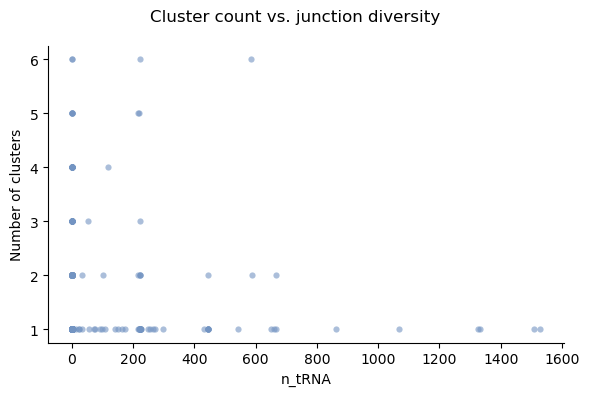

In [3]:
plot_cluster_count_vs_diversity(jdf_all, diversity_columns=["n_tRNA"], figsize=(6,4))

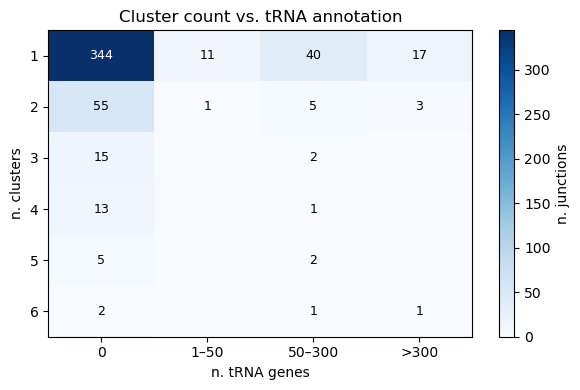

In [4]:
plot_junction_heatmap(jdf_all, x_col="trna_cat", y_col="n_clusters", heatmap_col="edge",
               x_label="n. tRNA genes", y_label="n. clusters", legend_label="n. junctions",
               title="Cluster count vs. tRNA annotation")